# **Experiment Notebook**



---
## Setup Environment

In [43]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT2/data


---
## Student Information

In [44]:
# <Student to fill this section>
student_name = "SUSHRUTA GANGADHAR PATIL"
student_id = "26273312"

In [45]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [46]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

### 0.b Import Packages

In [47]:
# <Student to fill this section>
import pandas as pd
import altair as alt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import label_binarize
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import (
    classification_report,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

---
## A. Experiment Description

In [48]:
# DO NOT MODIFY THE CODE IN THIS CELL
experiment_id = "1"
print_tile(size="h1", key='experiment_id', value=experiment_id)

In [49]:
experiment_hypothesis = """

A Decision Tree with class_weight='balanced' and tuned hyperparameters should
be able to classify all 5 vitamin deficiency conditions well above the dummy
baseline macro F1 of 0.1073.

The reason I'm starting with a Decision Tree is that vitamin deficiency
diagnosis actually follows logical if-then rules. Low serum_vitamin_d plus
bone pain points to Rickets. Night blindness combined with low vitamin_a_intake
points to Night_Blindness. A tree learns exactly these kinds of splits, and the
resulting rules are readable enough to make clinical sense.

The 12.5x class imbalance between Healthy and Scurvy is handled using
class_weight='balanced' so the model doesn't just learn to predict Healthy
for everything. GridSearchCV handles hyperparameter tuning systematically.

"""

In [50]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_hypothesis', value=experiment_hypothesis)

---
## B. Experiment Expectations

In [51]:
experiment_expectations = """

Target: macro F1 above 0.75 on the validation set, with actual recall on
Scurvy and Night_Blindness, not zeros like the baseline.

Three ways this could go:

1. It works well (macro F1 above 0.85): The symptom scores and serum biomarkers
   give the tree clean enough splits to separate all 5 classes. Minority classes
   get picked up because of balanced weighting.

2. It works partially (macro F1 between 0.70 and 0.85): Healthy, Anemia and
   Rickets come out fine but Scurvy and Night_Blindness still have low recall
   due to limited training samples. Next step would be Random Forest.

3. It doesn't work well enough (macro F1 below 0.70): The tree overfits on
   majority classes despite balancing. This would make the case for moving
   straight to an ensemble method.

"""

In [52]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='experiment_expectations', value=experiment_expectations)

---
## C. Data Understanding

In [53]:
# Do not modify this code
try:
  X_train = pd.read_csv(at.folder_path / 'X_train.csv')
  y_train = pd.read_csv(at.folder_path / 'y_train.csv')

  X_val = pd.read_csv(at.folder_path / 'X_val.csv')
  y_val = pd.read_csv(at.folder_path / 'y_val.csv')

  X_test = pd.read_csv(at.folder_path / 'X_test.csv')
  y_test = pd.read_csv(at.folder_path / 'y_test.csv')
except Exception as e:
  print(e)

In [54]:
# Shape and feature overview
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

# Class distribution in training set
print("\nClass distribution (train):")
print(y_train['disease_diagnosis'].value_counts())

# Feature summary
print("\nFeature types:")
print(X_train.dtypes.value_counts())

# Quick stats on key features
print("\nKey feature statistics:")
X_train.describe().round(2)

X_train shape: (3221, 29)
X_val shape:   (690, 29)
X_test shape:  (691, 29)

Class distribution (train):
disease_diagnosis
Healthy                 1182
Anemia                  1002
Rickets_Osteomalacia     808
Night_Blindness          134
Scurvy                    95
Name: count, dtype: int64

Feature types:
int64      15
float64    14
Name: count, dtype: int64

Key feature statistics:


,serum_vitamin_d,serum_vitamin_b12,serum_folate,vitamin_a_intake,vitamin_c_intake,vitamin_d_intake,vitamin_b12_intake,folate_intake,calcium_intake,iron_intake,...,Peripheral neuropathy,has_memory_problems,has_pale_skin,rickets_symptom_score,scurvy_symptom_score,anemia_symptom_score,night_blindness_symptom_score,diet_sun_risk,vitamin_d_calcium_product,vegan_b12_risk
count,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,...,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00,3221.00
mean,0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,...,0.35,0.30,0.16,0.57,0.32,0.65,0.38,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,0.48,0.46,0.37,0.78,0.53,0.84,0.58,1.00,1.00,1.00
min,-1.57,-1.26,-2.08,-2.19,-2.19,-1.61,-1.61,-2.31,-2.16,-2.04,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.45,-1.12,-1.61
25%,-0.73,-0.86,-0.75,-0.76,-0.75,-0.75,-0.80,-0.74,-0.73,-0.74,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.60,-0.70,-0.56
50%,-0.21,-0.22,-0.21,-0.12,-0.10,-0.21,-0.20,-0.13,-0.13,-0.12,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.25,-0.31,-0.56
75%,0.46,0.56,0.58,0.72,0.65,0.56,0.63,0.66,0.65,0.57,...,1.00,1.00,0.00,1.00,1.00,1.00,1.00,0.25,0.40,-0.18
max,4.32,5.49,2.88,3.34,4.39,4.77,4.93,3.64,3.65,4.07,...,1.00,1.00,1.00,2.00,2.00,2.00,2.00,1.94,5.77,2.32


---
## D. Feature Selection


In [55]:
features_list = [
    # Serum biomarkers
    'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',

    # Engineered symptom scores
    'rickets_symptom_score', 'scurvy_symptom_score',
    'anemia_symptom_score', 'night_blindness_symptom_score',

    # Engineered interaction features
    'diet_sun_risk', 'vitamin_d_calcium_product', 'vegan_b12_risk',

    # Raw intake columns missed earlier
    'vitamin_a_intake', 'vitamin_c_intake',

    # Lifestyle context
    'diet_type', 'sun_exposure_type', 'income_band',

    # General severity
    'symptoms_count'
]

In [56]:
feature_selection_explanations = """

16 features are selected for this experiment.

The 3 serum biomarkers, serum_vitamin_d, serum_vitamin_b12 and serum_folate
are the anchor of this feature set. They are direct blood measurements so they
give the tree hard numerical thresholds to split on.

The 4 engineered symptom scores replace the individual binary flags because they
give the tree a single continuous value to split on rather than multiple weak
binary columns. rickets_symptom_score averages 1.30 for Rickets versus 0.23 for
Healthy, scurvy_symptom_score averages 1.28 for Scurvy versus 0.03 for Healthy.
These gaps are large enough that even a shallow tree should pick them up early.

vitamin_a_intake and vitamin_c_intake are included as raw intake columns because
they are directly linked to Night_Blindness and Scurvy respectively and were not
captured in any engineered feature. Low vitamin_a_intake is a primary risk factor
for Night_Blindness and low vitamin_c_intake directly causes Scurvy leaving
these out would mean the model has no direct nutrient signal for the two weakest
performing classes.

vitamin_d_calcium_product and vegan_b12_risk bring in nutrient interaction effects
that a single intake column cannot capture alone.

diet_type, sun_exposure_type and income_band add lifestyle context the tree can
use independently on top of diet_sun_risk.

symptoms_count acts as a general severity indicator across all classes.

"""

In [57]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

In [58]:
X_train_model = X_train[features_list]
X_val_model   = X_val[features_list]
X_test_model  = X_test[features_list]

print(f"X_train_model shape: {X_train_model.shape}")
print(f"X_val_model shape:   {X_val_model.shape}")
print(f"X_test_model shape:  {X_test_model.shape}")

X_train_model shape: (3221, 16)
X_val_model shape:   (690, 16)
X_test_model shape:  (691, 16)


### E.1 Data Transformation <put_name_here>


In [59]:
data_transformation_1_explanations = """
All transformations were done in the preparation notebook, scaling, encoding,
imputation. Nothing left to do here. The splits load clean and ready to use.
"""

In [60]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

---
## F. Feature Engineering

### F.1 New Feature "\<put_name_here\>"



In [61]:
feature_engineering_1_explanations = """
No new features were created here. The preparation notebook already built the
key engineered features: symptom scores, diet_sun_risk, vitamin_d_calcium_product
and vegan_b12_risk. If this model struggles on Scurvy or Night_Blindness,
that's the signal to come back and engineer something more targeted in the
next experiment.
"""

In [62]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

---
## G. Train Machine Learning Model

### G.1 Import Algorithm


In [63]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV

In [64]:
algorithm_selection_explanations = """

Decision Tree with GridSearchCV is the first real model for this project.

The main reason for picking a Decision Tree is interpretability. Vitamin
deficiency diagnosis follows logical clinical rules, low serum_vitamin_d
plus bone pain points to Rickets, low vitamin_c_intake plus bleeding gums
points to Scurvy. A Decision Tree learns exactly these kinds of if-then
splits and produces rules a clinician can actually read and verify.

class_weight='balanced' is used to stop the tree from just learning to
predict Healthy all the time. With a 12.5x imbalance between Healthy and
Scurvy, an unweighted tree would ignore minority classes completely.

GridSearchCV handles hyperparameter tuning systematically across the
validation set, so the final tree is the best version found rather than
a default one.

"""

In [65]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### G.2 Set Hyperparameters

In [66]:
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy']
}

In [67]:
hyperparameters_selection_explanations = """

max_depth controls how deep the tree grows. A very deep tree memorises
the training data while a shallow one misses patterns. Testing from 3
up to None lets GridSearchCV find the right balance for this dataset.

min_samples_split and min_samples_leaf control when the tree stops
splitting. Higher values force more generalisation, which matters here
because Scurvy and Night_Blindness have very few training samples,
small leaf sizes would just overfit on them.

criterion tests both gini and entropy since they often behave differently
depending on class distribution. Letting the search decide which works
better is more reliable than picking one upfront.

All tuning uses f1_macro as the scoring metric, consistent with the
primary evaluation metric chosen in the baseline notebook.

"""

In [68]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### G.3 Fit Model

In [69]:
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_model, y_train.values.ravel())

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-val macro F1: {grid_search.best_score_:.4f}")

best_dt = grid_search.best_estimator_

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Best parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-val macro F1: 0.7409


### G.4 Model Technical Performance

In [70]:
y_val_pred = best_dt.predict(X_val_model)

macro_f1_val = f1_score(y_val, y_val_pred, average='macro')
print(f"Macro Average F1 (val): {macro_f1_val:.4f}")

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_val_pred))

Macro Average F1 (val): 0.6809

Classification Report (Validation):
                      precision    recall  f1-score   support

              Anemia       0.79      0.80      0.79       215
             Healthy       0.89      0.84      0.87       253
     Night_Blindness       0.44      0.59      0.50        29
Rickets_Osteomalacia       0.73      0.74      0.73       173
              Scurvy       0.53      0.50      0.51        20

            accuracy                           0.78       690
           macro avg       0.67      0.69      0.68       690
        weighted avg       0.79      0.78      0.78       690



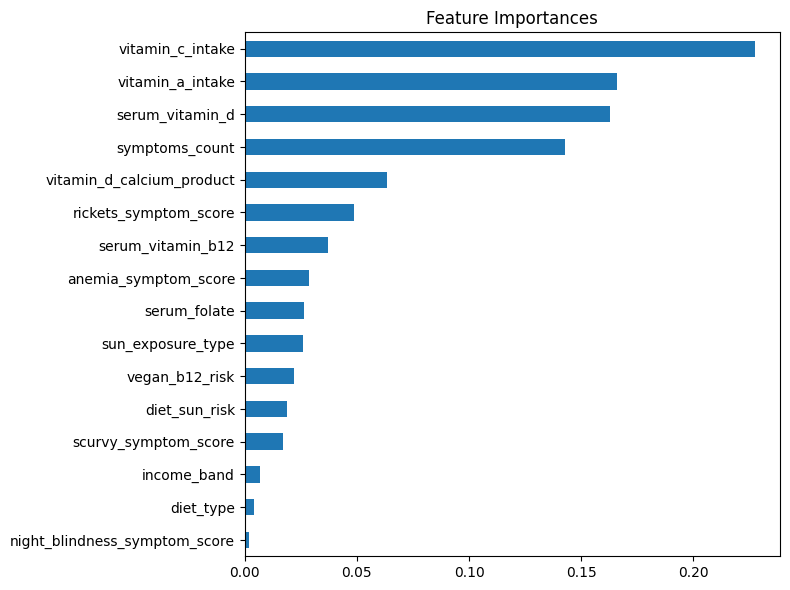

In [71]:
importances = pd.Series(best_dt.feature_importances_, index=features_list)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

In [72]:
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train_model, y_train.values.ravel())
y_val_dummy = dummy.predict(X_val_model)

classes = ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']

dummy_f1 = f1_score(y_val, y_val_dummy, average=None, labels=classes)
dt_f1 = f1_score(y_val, y_val_pred, average=None, labels=classes)

data = pd.DataFrame({
    'Class': classes * 2,
    'Model': ['Dummy'] * 5 + ['Decision Tree'] * 5,
    'F1 Score': [*dummy_f1.round(3), *dt_f1.round(3)]
})

chart = alt.Chart(data).mark_bar().encode(
    x=alt.X('Model:N', axis=alt.Axis(title=None, labels=False)),
    y=alt.Y('F1 Score:Q', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Model:N', scale=alt.Scale(
        domain=['Dummy', 'Decision Tree'],
        range=['#95a5a6', '#e67e22']
    )),
    column=alt.Column('Class:N', header=alt.Header(
        labelAngle=-45,
        labelAlign='right',
        labelFontSize=11
    )),
    tooltip=['Class', 'Model', alt.Tooltip('F1 Score:Q', format='.3f')]
).properties(
    width=80,
    height=300,
    title='F1 Score Comparison: Dummy vs Decision Tree'
)

print(f"Dummy Macro F1:         0.1073")
print(f"Decision Tree Macro F1: {macro_f1_val:.4f}")
print(f"Improvement:            +{macro_f1_val - 0.1073:.4f}")

chart

Dummy Macro F1:         0.1073
Decision Tree Macro F1: 0.6809
Improvement:            +0.5736


alt.Chart(...)

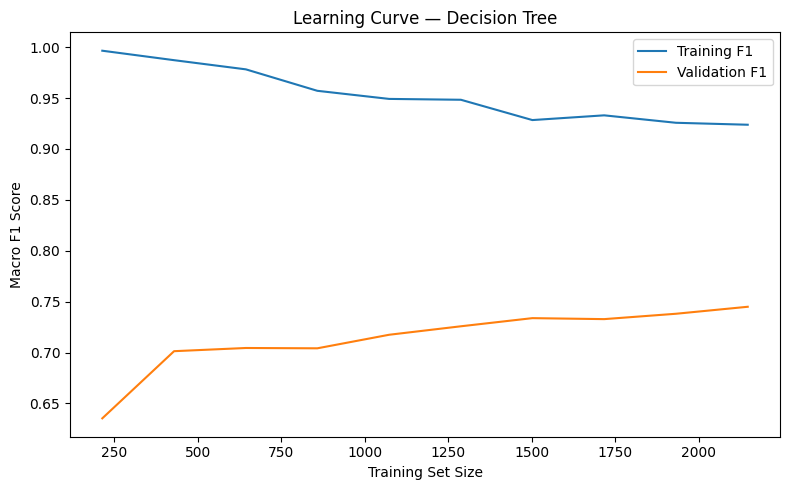

In [73]:
train_sizes, train_scores, val_scores = learning_curve(
    best_dt, X_train_model, y_train.values.ravel(),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, label='Training F1')
plt.plot(train_sizes, val_mean, label='Validation F1')
plt.xlabel('Training Set Size')
plt.ylabel('Macro F1 Score')
plt.title('Learning Curve — Decision Tree')
plt.legend()
plt.tight_layout()
plt.show()

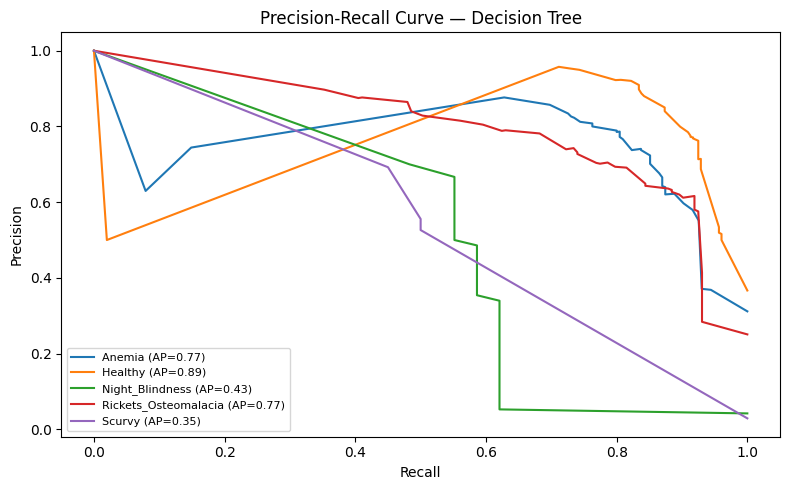

In [74]:
classes = ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']
y_val_bin = label_binarize(y_val, classes=classes)
y_val_prob = best_dt.predict_proba(X_val_model)

plt.figure(figsize=(8, 5))
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_val_prob[:, i])
    ap = average_precision_score(y_val_bin[:, i], y_val_prob[:, i])
    plt.plot(recall, precision, label=f'{cls} (AP={ap:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Decision Tree')
plt.legend(loc='lower left', fontsize=8)
plt.tight_layout()
plt.show()

In [75]:
classes = ['Anemia', 'Healthy', 'Night_Blindness', 'Rickets_Osteomalacia', 'Scurvy']

f1_scores = f1_score(y_val, y_val_pred, average=None, labels=classes)

data = pd.DataFrame({
    'Class': classes,
    'F1 Score': f1_scores.round(3)
})

chart = alt.Chart(data).mark_bar().encode(
    x=alt.X('Class:N', axis=alt.Axis(labelAngle=-30)),
    y=alt.Y('F1 Score:Q', scale=alt.Scale(domain=[0, 1])),
    color=alt.Color('Class:N', scale=alt.Scale(scheme='tableau10')),
    tooltip=['Class', alt.Tooltip('F1 Score:Q', format='.3f')]
).properties(
    width=400,
    height=300,
    title='Per-class F1 Score — Decision Tree'
)

chart

alt.Chart(...)

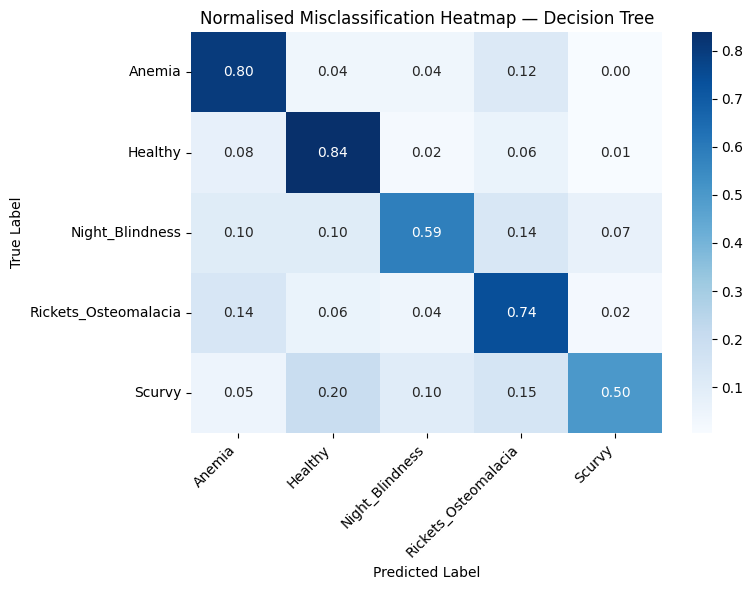

In [76]:
cm = confusion_matrix(y_val, y_val_pred, labels=classes)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.title('Normalised Misclassification Heatmap — Decision Tree')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [77]:
model_performance_explanations = """

The Decision Tree achieves a macro F1 of 0.6809 on the validation set, up from
0.1073 with the dummy baseline — an improvement of +0.5736.

The learning curve shows a large gap between training F1 (0.92) and validation
F1 (0.75), confirming the tree is overfitting. The validation curve is still
slowly rising at full training size, suggesting more data would help further.

The precision-recall curves tell the clearest story about class difficulty.
Healthy leads at AP=0.89 and Anemia and Rickets both at AP=0.77, these three
classes have enough training samples and clear enough feature boundaries for
the tree to learn well. Night_Blindness at AP=0.43 and Scurvy at AP=0.35 show
how little signal the tree can extract for these minority classes.

The normalised misclassification heatmap shows where predictions go wrong.
Scurvy is the most scattered, 20% of Scurvy patients are predicted as Healthy
and 15% as Rickets. Night_Blindness shows the most confused pattern overall
with misclassifications spread across all other classes, particularly 14%
going to Rickets  both conditions share muscle weakness and fatigue symptoms.

Every class now has non-zero recall compared to the dummy baseline. The dummy
model scored 0.0 on all disease classes. The Decision Tree gets 0.800 for
Anemia, 0.838 for Healthy, 0.586 for Night_Blindness, 0.740 for Rickets
and 0.500 for Scurvy.

"""

In [78]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

### G.5 Business Impact from Current Model Performance


In [79]:
business_impacts_explanations = """

The model is a clear improvement over dummy classifier predicting Healthy for everything, but
it is not ready for clinical use.

Anemia at 0.80 recall and Rickets at 0.74 recall are encouraging, these are
the two most common disease classes so getting them reasonably right matters.
But even here, missing 20% of Anemia cases and 26% of Rickets cases in a
screening context is still a real problem.

Scurvy is the biggest concern. Only 50% of cases are caught half of Scurvy
patients would walk away undiagnosed. Given that Scurvy is entirely preventable
with vitamin C supplementation, a missed diagnosis means continued deterioration
for something that a dietary change could fix.

Night_Blindness at 0.586 recall is better but the precision of 0.44 is low,
the model is incorrectly flagging Anemia and Healthy patients as Night_Blindness,
sending them for unnecessary vitamin A follow-ups and causing avoidable anxiety.

Healthy patients are handled at 0.84 recall, which at least means the model is
not over-diagnosing disease in healthy people, important for maintaining
clinician trust.

The cross-val to validation gap of 0.06 adds further concern. A model that
performs noticeably worse on unseen data than on training folds is not one
you would want making clinical recommendations.

"""

In [80]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## H. Experiment Outcomes

In [81]:
experiment_outcome = "Hypothesis Partially Confirmed"

In [82]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [83]:
experiment_results_explanations = """
The hypothesis is partially confirmed. The Decision Tree beat the dummy baseline
significantly. macro F1 went from 0.1073 to 0.6809, an improvement of +0.5736.
Every class now has non-zero recall. But the target of 0.75+ macro F1 was not
reached, and Scurvy and Night_Blindness still need work.

The key insight from this experiment is that vitamin_c_intake and vitamin_a_intake
are the two most important features in the model at 0.23 and 0.17 importance
respectively. These are direct nutrient signals for the two hardest classes
without them the model has no way to learn Scurvy and Night_Blindness boundaries
reliably.

The cross-val macro F1 of 0.7409 versus validation 0.6809 shows a gap of 0.06,
suggesting the single tree is overfitting to some degree. A Decision Tree makes
hard splits and has high variance, which hurts minority class boundaries on
unseen data.

Next steps in priority order:

1. Random Forest (Experiment 2) — highest expected gain. Averaging across many
   trees reduces variance and should close the cross-val to validation gap.
   With the 16 feature set now established, expect macro F1 to push toward 0.80+.

2. Feature engineering targeting Night_Blindness (Experiment 3)
   night_blindness_symptom_score contributed almost nothing to the model.
   A direct interaction between vitamin_a_intake and has_night_blindness
   might produce a stronger signal for this class.

3. SMOTE oversampling (Experiment 4) with only 95 Scurvy and 134
   Night_Blindness training samples, synthetic oversampling could help
   any model learn better boundaries for these classes.
"""

In [84]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)